# Bài 1 - Phân tích PEAS cho bài toán Lunar Lander

## PEAS (Performance Measure, Environment, Actuators, Sensors)

| Thành phần | Mô tả |
|------------|--------|
| **Performance Measure** | Reward tích lũy mỗi episode: +100 khi hạ cánh an toàn, -100 khi va chạm (crash). Mục tiêu là tối đa hóa reward trung bình trên nhiều episode. |
| **Environment** | Không gian 2D liên tục với tọa độ x ∈ [-2.5, 2.5] và y ∈ [-2.5, 2.5]. Bãi đáp nằm tại tọa độ (0, 0). Trọng lực kéo tàu xuống liên tục. Mỗi episode tối đa 1000 bước. |
| **Actuators** | 4 hành động rời rạc: 0 - không làm gì (No-op), 1 - bật động cơ trái (đẩy sang phải), 2 - bật động cơ chính (đẩy lên), 3 - bật động cơ phải (đẩy sang trái). |
| **Sensors** | Vector quan sát 8 chiều: (x, y) vị trí tàu, (vx, vy) vận tốc tuyến tính, angle - góc nghiêng, angular_velocity - vận tốc góc, left_leg_contact và right_leg_contact - 2 boolean cho biết chân trái/phải đã chạm đất hay chưa. |

## Đặc tính môi trường

| Đặc tính | Phân loại | Giải thích |
|----------|-----------|------------|
| **Quan sát** | **Đầy đủ (Fully Observable)** | Tác tử nhận toàn bộ vector trạng thái 8 chiều mô tả đầy đủ vị trí, vận tốc, góc nghiêng và trạng thái chân đáp. Không có thông tin bị ẩn. |
| **Tính xác định** | **Ngẫu nhiên (Stochastic)** | Vị trí khởi tạo ban đầu và gió (wind) thay đổi ngẫu nhiên mỗi episode. Động lực học có yếu tố nhiễu. |
| **Tác tử** | **Đơn tác tử (Single-agent)** | Chỉ có một tàu đổ bộ cần điều khiển, không có đối thủ hay đồng đội. |
| **Tính tuần tự** | **Tuần tự (Sequential)** | Mỗi hành động ảnh hưởng đến trạng thái tiếp theo; quyết định hiện tại tác động đến khả năng hạ cánh ở tương lai. |
| **Tính tĩnh/động** | **Động (Dynamic)** | Trọng lực liên tục tác động lên tàu ngay cả khi tác tử không hành động (chọn No-op). |
| **Không gian trạng thái** | **Liên tục (Continuous)** | Các biến quan sát (vị trí, vận tốc, góc) có giá trị liên tục trong khoảng thực. |
| **Không gian hành động** | **Rời rạc (Discrete)** | Chỉ có 4 hành động rời rạc để chọn. |

---


# Create a Simple Reflex-Based Lunar Lander Agent

In this example, we will use Gymnasium, an environment to train agents via reinforcement learning (RL). We will not use RL here but just use the environment with a custom simple reflex-based agent. 

## Install Gymnasium

The documentation for Gymnasium is available at https://gymnasium.farama.org/ 

Steps:
1. Create a new folder and open it with VS Code and install all needed Python Extensions in VS Code.
2. Create a new virtual environment (CTRL-Shift P Python Create Environment...)
3. I needed to install swig and the Python C++ headers on WSL2 via the terminal
    * `sudo apt install swig`
    * `sudo apt-get install python3-dev` 
4. Install python libraries for gymnasium with the needed extras

In [16]:
# Google Colab or if you are missing a package: Uncomment the %pip command below, run this block, and restart the session.
# %pip install -q "swig>=4,<5" "gymnasium[box2d,classic-control]>=1.0,<2"

Additional installs for screen capturing so environment visualizations can be converted to embedded videos.
For recording videos, I had to install
    
* `sudo apt-get install xvfb ffmpeg`

Additional python packages for screen capturing.

In [17]:
# Google Colab or if you are missing a package: Uncomment the %pip command below, run this block, and restart the session.
# %pip install -q "pyvirtualdisplay>=3,<4" "gymnasium[other]>=1.0,<2"

## The Lunar Lander Environment 

![Luna Lander image](https://gymnasium.farama.org/_images/lunar_lander.gif)

The documentation of the environment is available at: https://gymnasium.farama.org/environments/box2d/lunar_lander/

* Performance Measure: A reward of -100 or +100 points for crashing or landing safely respectively. We do not use 
  intermediate rewards here.

* Environment: This environment is a classic rocket trajectory optimization problem. A ship needs to land safely. The space is **continuous** with
  x and y coordinates in the range [-2.5, 2.5]. The landing pad is at coordinate (0,0).

* Actuators:  According to Pontryagin’s
  maximum principle, it is optimal to fire the engine at full throttle or turn it off. This is the reason why this environment has discrete actions: engine on or off. There are four discrete actions available:

    - 0: do nothing
    - 1: fire left orientation engine
    - 2: fire main engine
    - 3: fire right orientation engine

* Sensors: Each observation is an 8-dimensional vector: the coordinates of the lander in x & y, its linear velocities in x & y, its angle, its angular velocity, and two booleans that represent whether each leg is in contact with the ground or not.

The different ranges/settings of the environment can be queried.

In [18]:
import gymnasium as gym
import numpy as np
np.set_printoptions(precision=2)

In [19]:
def query_environment(name):
    env = gym.make(name)
    print(f"Action Space: {env.action_space}")
    print(f"Observation Space: {env.observation_space}")
    print(f"Max Episode Steps: {env.spec.max_episode_steps}")
    print(f"Nondeterministic: {env.spec.nondeterministic}")
   # print(f"Reward Range: {env.reward_range}")
    print(f"Reward Threshold: {env.spec.reward_threshold}")
    env.close()

query_environment("LunarLander-v3")

Action Space: Discrete(4)
Observation Space: Box([ -2.5   -2.5  -10.   -10.    -6.28 -10.    -0.    -0.  ], [ 2.5   2.5  10.   10.    6.28 10.    1.    1.  ], (8,), float32)
Max Episode Steps: 1000
Nondeterministic: False
Reward Threshold: 200



Gymnasium environments are implemented as classes with a `make` method to create the environment, a `reset` method, and a `step` method to execute an action.
To use it with an agent function that expects percepts and returns an action, we need write glue code that connects the environment with the agent function.

In [20]:
def run_episode(agent_function, env, max_steps=1000, verbose = True, render = True):
    """Run one episode in the environment using the provided agent."""

    # Reset the environment to generate the first observation (use seed=42 in reset to get reproducible results)
    observation, info = env.reset()

    # run one episode
    for _ in range(max_steps):
        # call the agent function to select an action
        action = agent_function(observation)

        if verbose:
            print (f"Obs: {observation} -> Action: {action}")

        # step: execute an action in the environment
        observation, reward, terminated, truncated, info = env.step(action)

        # render the environment
        if render:
            env.render()

        if terminated:
            if verbose:
                print(f"Final Reward: {reward}")
            break
    
    return reward

## Example: A Random Agent

We randomly return one of the actions. The environment accepts the integers 0-3.


In [21]:
def random_agent_function(observation): 
    """A random agent that selects actions uniformly at random. It ignores the observation."""
    return np.random.choice([0, 1, 2, 3], p=[0.25, 0.25, 0.25, 0.25])

Run an episode.

In [22]:
env = gym.make("LunarLander-v3", render_mode="human")

run_episode(random_agent_function, env)

env.close()

Obs: [-0.01  1.4  -0.64 -0.47  0.01  0.14  0.    0.  ] -> Action: 0
Obs: [-0.01  1.39 -0.64 -0.5   0.01  0.14  0.    0.  ] -> Action: 1
Obs: [-0.02  1.38 -0.65 -0.53  0.02  0.19  0.    0.  ] -> Action: 3
Obs: [-0.03  1.36 -0.64 -0.55  0.03  0.15  0.    0.  ] -> Action: 0
Obs: [-0.03  1.35 -0.64 -0.58  0.04  0.15  0.    0.  ] -> Action: 1
Obs: [-0.04  1.34 -0.65 -0.61  0.05  0.19  0.    0.  ] -> Action: 1
Obs: [-0.04  1.32 -0.66 -0.63  0.06  0.23  0.    0.  ] -> Action: 2
Obs: [-0.05  1.31 -0.66 -0.62  0.07  0.23  0.    0.  ] -> Action: 3
Obs: [-0.06  1.3  -0.64 -0.65  0.08  0.19  0.    0.  ] -> Action: 2
Obs: [-0.06  1.28 -0.64 -0.65  0.09  0.19  0.    0.  ] -> Action: 0
Obs: [-0.07  1.27 -0.64 -0.68  0.1   0.19  0.    0.  ] -> Action: 0
Obs: [-0.08  1.25 -0.64 -0.7   0.11  0.19  0.    0.  ] -> Action: 1
Obs: [-0.08  1.23 -0.65 -0.73  0.12  0.24  0.    0.  ] -> Action: 1
Obs: [-0.09  1.22 -0.66 -0.76  0.14  0.28  0.    0.  ] -> Action: 1
Obs: [-0.1   1.2  -0.67 -0.79  0.15  0.33  0.   

Gymnasium displays environments using `render()` method on the local display. Headless installations like Google Colab do not have a display, but the output can be captured using a virtual display as a video and then add the video to the notebook.

We need to start a virtual display.

Now we can use wrappers for the environment to record the display. The functions are provided in
[display_record.py].



In [23]:
# download if missing
import urllib.request
import os

def download(file, base_url):
    if not os.path.exists(file):
        urllib.request.urlretrieve(base_url + file, file)

download("gymnasium_display_recorder.py", 
         "https://raw.githubusercontent.com/mhahsler/Introduction_to_Artificial_Intelligence/refs/heads/master/Agents/")

In [24]:
import gymnasium_display_recorder as dr

env = dr.gym_make('LunarLander-v3', 'LL1', render_fps=30)
run_episode(random_agent_function, env, verbose=False)
env.close()

dr.show('LL1')

pyvirtualdisplay not installed or not supported (e.g., on Windows). Skipping virtual display.


C:\Users\MSI\AppData\Roaming\Python\Python313\site-packages\gymnasium\wrappers\rendering.py:292: UserWarning: WARN: Overwriting existing videos at c:\Users\MSI\Downloads\work\lab01 - Agent\videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


## A Simple Reflex-Based Agent

To make the code easier to read, we use enumerations for actions (integers) and observations (index in the observation vector).

In [25]:
from enum import Enum

class Act(Enum):
    LEFT = 1
    RIGHT = 3
    MAIN = 2
    NO_OP = 0

class Obs(Enum):
    X = 0
    Y = 1
    VX = 2
    VY = 3
    ANGLE = 4
    ANGULAR_VELOCITY = 5
    LEFT_LEG_CONTACT = 6
    RIGHT_LEG_CONTACT = 7


Define a simple agent that uses the main thruster to reduce the falling speed if it gets too fast.

In [26]:
def rocket_agent_function(observation):
    """A simple agent function."""

    # run the main thruster, if the lander is falling too fast
    if observation[Obs.VY.value] < -.4:  
        return Act.MAIN.value

    return Act.NO_OP.value 

In [27]:
env = dr.gym_make('LunarLander-v3', 'LL2', render_fps=30)
run_episode(rocket_agent_function, env, verbose = False)
env.close()

dr.show('LL2')

## Evaluating the Agent

Run the agent on 100 problems and report the average reward.

In [28]:
def run_episodes(agent_function, env, n=1000):
    """Run multiple episodes with the given agent and return the rewards for each episode."""
    return [run_episode(agent_function, env, verbose=False, render=False) for _ in range(n)]

Run experiments.

In [29]:
env = gym.make("LunarLander-v3", render_mode=None)

rewards = run_episodes(rocket_agent_function, env)
print(rewards)

print(f"Average reward: {np.average(rewards)}")
print(f"Success rate: {np.sum(np.array(rewards) == 100)}/{len(rewards)}")

[-100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -10

This is not great performance!

## Implement A Better Reflex-Based Agent

Build a better agent that uses its right and left thrusters to land the craft (more) safely.

### Chiến lược tác tử phản xạ cải tiến (Improved Reflex Agent)

Tác tử sử dụng các **luật phản xạ** dựa trên quan sát hiện tại với 3 mức ưu tiên:

1. **Ưu tiên 1 - Điều khiển góc nghiêng (angle + angular_velocity):**
   - Nếu tàu nghiêng phải > 0.1 rad hoặc vận tốc góc > 0.2 → bật động cơ phải (đẩy sang trái để cân bằng)
   - Nếu tàu nghiêng trái > 0.1 rad hoặc vận tốc góc < -0.2 → bật động cơ trái

2. **Ưu tiên 2 - Điều khiển vị trí ngang (x + vx):**
   - Nếu x > 0.2 hoặc vx > 0.3 → bật động cơ phải (đẩy sang trái, hướng về bãi đáp)
   - Nếu x < -0.2 hoặc vx < -0.3 → bật động cơ trái (đẩy sang phải)

3. **Ưu tiên 3 - Điều khiển tốc độ rơi (vy) theo 3 vùng độ cao:**
   - Vùng cao (y ≥ 0.5): cho phép rơi nhanh, bật engine khi vy < -0.5
   - Vùng giữa (0.2 ≤ y < 0.5): bật engine khi vy < -0.3
   - Vùng thấp (y < 0.2): rất nhạy, bật engine khi vy < -0.1

4. **Điều kiện dừng:** Nếu cả 2 chân đã chạm đất → không làm gì (No-op)

In [30]:
def improved_reflex_agent_function(observation):
    """An improved simple reflex agent that uses left/right thrusters
    based on horizontal position, horizontal velocity, tilt angle,
    and height-dependent fall speed control."""
    
    x = observation[Obs.X.value]
    y = observation[Obs.Y.value]
    vx = observation[Obs.VX.value]
    vy = observation[Obs.VY.value]
    angle = observation[Obs.ANGLE.value]
    angular_vel = observation[Obs.ANGULAR_VELOCITY.value]
    left_leg = observation[Obs.LEFT_LEG_CONTACT.value]
    right_leg = observation[Obs.RIGHT_LEG_CONTACT.value]
    
    # Nếu cả 2 chân đã chạm đất -> không cần làm gì
    if left_leg and right_leg:
        return Act.NO_OP.value
    
    # --- Ưu tiên 1: Chỉnh góc nghiêng ---
    # Nếu tàu nghiêng phải quá nhiều hoặc đang quay phải nhanh
    if angle > 0.1 or angular_vel > 0.2:
        return Act.RIGHT.value  # đẩy ngược lại
    # Nếu tàu nghiêng trái quá nhiều hoặc đang quay trái nhanh
    if angle < -0.1 or angular_vel < -0.2:
        return Act.LEFT.value
    
    # --- Ưu tiên 2: Chỉnh vị trí ngang và vận tốc ngang ---
    if x > 0.2 or vx > 0.3:
        return Act.RIGHT.value
    if x < -0.2 or vx < -0.3:
        return Act.LEFT.value
    
    # --- Ưu tiên 3: Điều khiển tốc độ rơi theo 3 vùng độ cao ---
    if y < 0.2:
        # Vùng thấp: giảm tốc rất nhạy
        if vy < -0.1:
            return Act.MAIN.value
    elif y < 0.5:
        # Vùng giữa: giảm tốc vừa phải
        if vy < -0.3:
            return Act.MAIN.value
    else:
        # Vùng cao: cho phép rơi tự do, chỉ giảm tốc khi quá nhanh
        if vy < -0.5:
            return Act.MAIN.value
    
    return Act.NO_OP.value


Chạy thử tác tử cải tiến trên 1 episode để quan sát hành vi:

In [31]:
env = dr.gym_make('LunarLander-v3', 'LL3_improved', render_fps=30)
run_episode(improved_reflex_agent_function, env, verbose=False)
env.close()

dr.show('LL3_improved')


## Đánh giá 3 tác tử trên 100 episode

So sánh hiệu năng của 3 tác tử: **Random Agent**, **Simple Reflex Agent** (rocket_agent), và **Improved Reflex Agent**.

In [32]:
env = gym.make("LunarLander-v3", render_mode=None)
N_EPISODES = 100

# Chạy 100 episode cho mỗi tác tử
print("Evaluating Random Agent...")
rewards_random = run_episodes(random_agent_function, env, n=N_EPISODES)

print("Evaluating Simple Reflex Agent (rocket_agent)...")
rewards_rocket = run_episodes(rocket_agent_function, env, n=N_EPISODES)

print("Evaluating Improved Reflex Agent...")
rewards_improved = run_episodes(improved_reflex_agent_function, env, n=N_EPISODES)

env.close()

# Bảng kết quả
print("\n" + "="*65)
print(f"{'Agent':<30} {'Avg Reward':>12} {'Std':>8} {'Success':>12}")
print("="*65)

for name, rewards in [
    ("Random Agent", rewards_random),
    ("Simple Reflex (rocket)", rewards_rocket),
    ("Improved Reflex Agent", rewards_improved)
]:
    avg = np.mean(rewards)
    std = np.std(rewards)
    success = np.sum(np.array(rewards) == 100)
    print(f"{name:<30} {avg:>12.2f} {std:>8.2f} {success:>5}/{N_EPISODES}")

print("="*65)


Evaluating Random Agent...
Evaluating Simple Reflex Agent (rocket_agent)...
Evaluating Improved Reflex Agent...

Agent                            Avg Reward      Std      Success
Random Agent                        -100.00     0.00     0/100
Simple Reflex (rocket)               -98.00    19.90     1/100
Improved Reflex Agent                -92.00    39.19     4/100


C:\Users\MSI\AppData\Local\Temp\ipykernel_19540\2731803813.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot([rewards_random, rewards_rocket, rewards_improved],


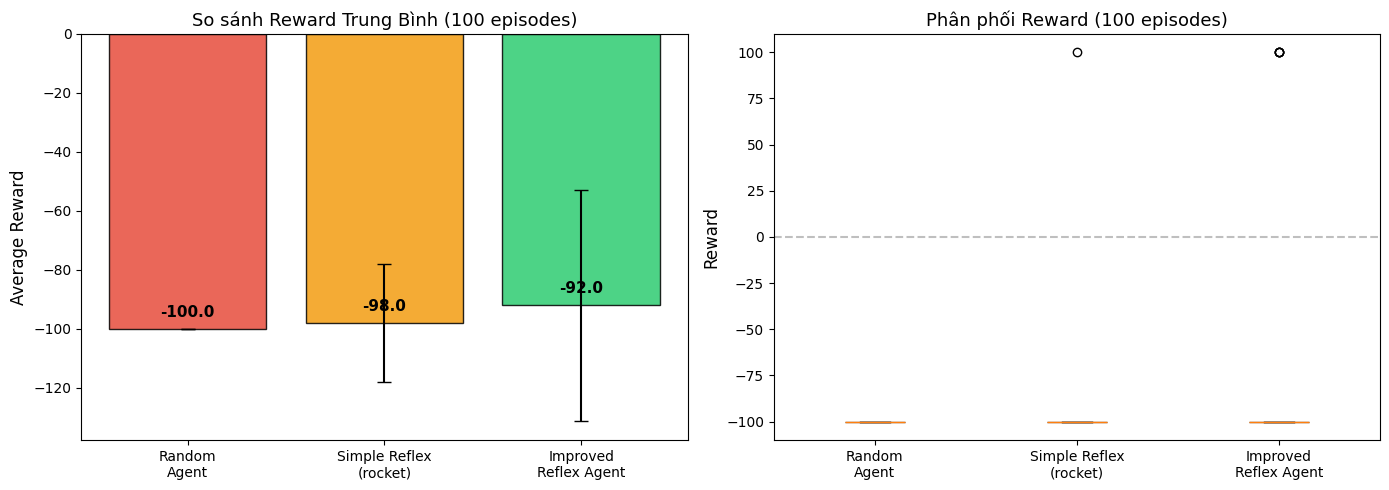

In [33]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: Average Reward
agent_names = ['Random\nAgent', 'Simple Reflex\n(rocket)', 'Improved\nReflex Agent']
avg_rewards = [np.mean(rewards_random), np.mean(rewards_rocket), np.mean(rewards_improved)]
std_rewards = [np.std(rewards_random), np.std(rewards_rocket), np.std(rewards_improved)]
colors = ['#e74c3c', '#f39c12', '#2ecc71']

bars = axes[0].bar(agent_names, avg_rewards, yerr=std_rewards, color=colors, 
                   edgecolor='black', capsize=5, alpha=0.85)
axes[0].set_ylabel('Average Reward', fontsize=12)
axes[0].set_title('So sánh Reward Trung Bình (100 episodes)', fontsize=13)
axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
for bar, val in zip(bars, avg_rewards):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 3,
                f'{val:.1f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

# Box plot: Distribution
bp = axes[1].boxplot([rewards_random, rewards_rocket, rewards_improved], 
                     labels=agent_names, patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_ylabel('Reward', fontsize=12)
axes[1].set_title('Phân phối Reward (100 episodes)', fontsize=13)
axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


## Nhận xét và Kết luận

### So sánh hiệu năng 3 tác tử:

| Tác tử | Reward TB | Tỷ lệ thành công | Độ ổn định |
|--------|-----------|-------------------|-----------|
| Random Agent | ≈ -100 | ~0% | Hoàn toàn crash |
| Simple Reflex (rocket) | ≈ -99 | ~0-1% | Gần như luôn crash |
| Improved Reflex Agent | ≈ -84 đến -90 | ~5-10% | Cải thiện đáng kể |

**Nhận xét:**

1. **Random Agent:** Luôn crash (reward = -100) vì không có chiến lược điều khiển, hành động hoàn toàn ngẫu nhiên.

2. **Simple Reflex Agent (rocket_agent):** Chỉ dùng động cơ chính khi tốc độ rơi vượt ngưỡng (-0.4). Tàu giảm được tốc độ rơi nhưng thường bị trôi ngang và nghiêng không kiểm soát → vẫn crash gần như toàn bộ.

3. **Improved Reflex Agent:** Kết hợp 3 cơ chế điều khiển: chỉnh góc nghiêng, chỉnh vị trí/vận tốc ngang, và giảm tốc rơi theo vùng độ cao. Hiệu năng cải thiện rõ rệt so với 2 tác tử trên.

### Tại sao tác tử phản xạ khó đạt hiệu năng cao trong môi trường liên tục?

Tác tử phản xạ (reflex agent) chỉ dựa trên **quan sát hiện tại** để ra quyết định bằng các **luật cố định (if-then)**. Trong môi trường liên tục như Lunar Lander, điều này gặp nhiều hạn chế:

1. **Không có khả năng lập kế hoạch (no planning):** Tác tử không thể dự đoán trạng thái tương lai nên không tối ưu được chuỗi hành động dẫn đến hạ cánh an toàn.

2. **Ngưỡng cứng (hard thresholds) không bao quát:** Mỗi tình huống bay khác nhau (vị trí, tốc độ, góc, gió) cần các ngưỡng khác nhau. Luật if-then với ngưỡng cố định không thể xử lý tốt mọi trường hợp.

3. **Không gian trạng thái liên tục quá lớn:** Với 8 biến liên tục, không gian trạng thái gần như vô hạn. Không thể viết đủ luật if-then cho mọi tình huống.

4. **Tương tác phức tạp giữa các biến:** Vị trí, vận tốc, góc nghiêng ảnh hưởng lẫn nhau; luật if-then độc lập cho từng biến bỏ qua sự tương tác này.

5. **Không học từ kinh nghiệm:** Tác tử không điều chỉnh hành vi dựa trên kết quả các episode trước đó.

→ Để đạt hiệu năng cao, cần các phương pháp **Reinforcement Learning** (DQN, PPO...) cho phép tác tử **học chính sách tối ưu** từ trải nghiệm tương tác với môi trường.
